In [1]:
import os
import pandas as pd
import numpy as np
import importlib
import pickle

from Soccer_OCEL.idsse_import import get_games, load_game_data
from Soccer_OCEL.role_objects import assign_roles_multi
import Soccer_OCEL.utils as utils

from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
import pm4py

from pm4py.algo.discovery.dfg.variants import clean_time
from pm4py.visualization.dfg.variants import timeline as timeline_gviz_generator
from pm4py.visualization.dfg import visualizer as dfg_visualizer

In [5]:
#load all
path='data/28196177'
#games=get_games(path)
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        #GD_loaded.join_events(log='MOVEMENT')
        GD_loaded=assign_roles_multi(GD_loaded, team=True)
        GD_loaded.format_log()
    all_games.append(GD_loaded.events)
allgame_df=pd.concat(all_games).sort_values(["attribute:game","attribute:session", "attribute:frame"]).reset_index(drop=True)

In [23]:
allgame_df.query('`Player`.isna()')

,level_0,concept:name,attribute:gameclock,tID,Player,attribute:outcome,time:timestamp,minute,second,attribute:qualifier,...,DeflectionPlayer,PlayersInBox,GoalkeeperMovement,GoalkeeperBehaviour,FouledPlayer,ProspectiveTaker,RetakenPenalty,PenaltyExecution,PenaltyDirection,AssistFouledPlayer
236,130,Pass_Intercepted,349.725,None,NaN,0.0,2022-11-05 12:07:17.535000+00:00,5.0,49.0,"{'Evaluation': 'unsuccessful', 'Distance': 'me...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
281,157,ThrowIn,442.655,DFL-CLU-00000P,None,NaN,2022-11-05 12:08:50.465000+00:00,7.0,22.0,"{'Side': 'left', 'Team': 'DFL-CLU-00000P', 'De...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448,248,Pass_Intercepted,795.702,None,NaN,0.0,2022-11-05 12:14:43.512000+00:00,13.0,15.0,"{'Evaluation': 'unsuccessful', 'Distance': 'me...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
543,301,Cross_Intercepted,1020.823,None,NaN,0.0,2022-11-05 12:18:28.633000+00:00,17.0,0.0,"{'Evaluation': 'unsuccessful', 'Rotation': 'aw...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
672,374,Pass_Intercepted,1236.658,None,NaN,0.0,2022-11-05 12:22:04.468000+00:00,20.0,36.0,"{'Evaluation': 'unsuccessful', 'Distance': 'me...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
779,436,Pass_Intercepted,1476.918,None,NaN,0.0,2022-11-05 12:26:04.728000+00:00,24.0,36.0,"{'Evaluation': 'unsuccessful', 'Distance': 'lo...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
861,478,Pass_Intercepted,1595.746,None,NaN,0.0,2022-11-05 12:28:03.556000+00:00,26.0,35.0,"{'Evaluation': 'unsuccessful', 'Distance': 'lo...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
884,489,Pass_Intercepted,1642.609,None,NaN,0.0,2022-11-05 12:28:50.419000+00:00,27.0,22.0,"{'Evaluation': 'unsuccessful', 'Distance': 'sh...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1013,563,RefereeBall,1909.140,None,None,NaN,2022-11-05 12:33:16.950000+00:00,31.0,49.0,{},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1171,654,Pass_Intercepted,2242.680,None,NaN,0.0,2022-11-05 12:38:50.490000+00:00,37.0,22.0,"{'Evaluation': 'unsuccessful', 'Distance': 'lo...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
allgame_df.query('`Player`.isna()').iloc[0][allgame_df.query('`Player`.isna()').iloc[0].notna()]['attribute:qualifier']

{'Evaluation': 'unsuccessful',
 'Distance': 'medium',
 'SemiField': 'false',
 'PlayOrigin': 'ownHalf',
 'Height': 'high',
 'PlayAngle': '95.38',
 'FlatCross': 'false',
 'PenaltyBox': 'false',
 'Player': 'DFL-OBJ-0026V5',
 'Team': 'DFL-CLU-00000H',
 'FromOpenPlay': 'true',
 'BallPossessionPhase': '140',
 'FreeKickLayup': 'false'}

In [34]:
allgame_df.query('`concept:name`=="Play_Pass"').iloc[0][allgame_df.query('`concept:name`=="Play_Pass"').iloc[0].notna()]

level_0                                                                1
concept:name                                                   Play_Pass
attribute:gameclock                                                2.097
tID                                                       DFL-CLU-00000H
Player                                                    DFL-OBJ-002GN4
attribute:outcome                                                    0.0
time:timestamp                          2022-11-05 12:01:29.907000+00:00
minute                                                               0.0
second                                                               2.0
attribute:qualifier    {'Evaluation': 'unsuccessful', 'Distance': 'lo...
attribute:session                                                      1
Evaluation                                                  unsuccessful
Distance                                                            long
SemiField                                          

In [7]:
games=['J03WQQ']#, 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf
#games=['J03WQQ', 'J03WOH', 'J03WOY']#Fortuna Düsseldorf, won games
#games=['J03WR9', 'J03WPY']#Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('output','output_pkl',f"GameData_{Game}_WithPassDIR.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
    GD_loaded.format_log()
    df= GD_loaded.events
    df['pteam'] = df['Player'].apply(lambda pid: utils.get_teamside_from_pID(pid, GD_loaded.team_sheets_df) if pd.notnull(pid) else None)
    all_games.append(df)
allgame_df=pd.concat(all_games).sort_values('time:timestamp').reset_index(drop=True)

In [35]:
GD_loaded.movement_events.iloc[0][GD_loaded.movement_events.iloc[0].notna()]

pID                                  DFL-OBJ-0000F8
Session                                           1
eID                                         Forward
Frame                                             0
end_frame                                         0
movement                                   0.107703
dx                                             -0.1
dy                                            -0.04
angle                                    201.801409
angle_attacking                           21.801409
Team                                           Home
x                                             52.18
y                                             54.45
Dist_ball                                 21.076558
gameclock                                       0.0
timestamp          2022-09-10 20:31:31.610000+02:00
geometry                        POINT (52.18 54.45)
ball_loc                        POINT (47.16 33.98)
dir_8_num                                         0
duration_fra

In [55]:
allgame_df.rename(columns={'role':'org:resource'}, inplace=True)

In [56]:
import pm4py.algo.organizational_mining.roles.variants.pandas as role_mining

role_mining.apply(allgame_df)

[Activities: ['Backward', 'Backward-Left', 'Backward-Right', 'Ball_lost', 'BlockedShot', 'Caution', 'CornerKick_Play_Cross', 'Cross_Received', 'Forward', 'Forward-Left', 'Forward-Right', 'Foul', 'Left', 'Nutmeg', 'OtherBallAction', 'OutSubstitution', 'Pass_Received', 'Play_Cross', 'Play_Pass', 'Right', 'SavedShot', 'Scored', 'ShotAtGoal', 'SpectacularPlay', 'TacklingGame', 'ThrowIn_Play_Cross'] Originators importance {'Defender': 151608, 'Forward': 40221, 'Goalkeeper': 11990, 'Midfielder': 166055, 'Unknown': 69167},
 Activities: ['FreeKick_Play_Cross', 'OtherPlayerAction', 'Penalty_ShotAtGoal', 'ShotWoodWork', 'SitterPrevented'] Originators importance {'Midfielder': 12, 'Unknown': 1},
 Activities: ['Cross_Intercepted', 'Pass_Intercepted', 'PossessionLossBeforeGoal', 'ThrowIn_Play_Pass'] Originators importance {'Defender': 553, 'Forward': 24, 'Goalkeeper': 39, 'Midfielder': 179, 'Unknown': 108},
 Activities: ['CornerKick_Play_Pass', 'OtherShot', 'Run', 'ShotWide'] Originators importance

In [35]:
event_log = pm4py.convert_to_event_log(allgame_df)
variants = pm4py.get_variants(event_log)
variants

{('KickOff_Play_Pass',
  'Pass_Received',
  'Play_Pass',
  'Ball_lost'): [{'attributes': {'concept:name': 'J03WQQ_Away_1'}, 'events': [{'level_0': 0, 'concept:name': 'KickOff_Play_Pass', 'attribute:gameclock': 0.0, 'tID': 'DFL-CLU-00000H', 'Player': 'DFL-OBJ-002GNL', 'attribute:outcome': 1.0, 'time:timestamp': Timestamp('2022-11-05 12:01:27.810000+0000', tz='UTC'), 'minute': 0.0, 'second': 0.0, 'attribute:qualifier': {'TeamLeft': 'DFL-CLU-00000H', 'GameSection': 'firstHalf', 'TeamRight': 'DFL-CLU-00000P', 'Evaluation': 'successfullyCompleted', 'Distance': 'short', 'SemiField': 'false', 'PlayOrigin': 'ownHalf', 'Height': 'flat', 'PlayAngle': '162.96', 'FlatCross': 'false', 'PenaltyBox': 'false', 'Player': 'DFL-OBJ-002GNL', 'Team': 'DFL-CLU-00000H', 'Recipient': 'DFL-OBJ-002GN4', 'FromOpenPlay': 'false', 'BallPossessionPhase': '6', 'FreeKickLayup': 'false'}, 'attribute:session': 1, 'TeamLeft': 'DFL-CLU-00000H', 'GameSection': 'firstHalf', 'TeamRight': 'DFL-CLU-00000P', 'Evaluation': 'suc

In [17]:
diff_rows.iloc[0][diff_rows.iloc[0].notna()]

level_0                                                                  40
concept:name                                                      SavedShot
attribute:gameclock                                                 113.954
tID                                                          DFL-CLU-00000H
Player                                                       DFL-OBJ-00008K
attribute:outcome                                                       0.0
time:timestamp                             2022-11-05 12:03:21.764000+00:00
minute                                                                  1.0
second                                                                 53.0
attribute:qualifier       {'BuildUp': 'passOpenPlay', 'CounterAttack': '...
attribute:session                                                         1
attribute:team                                                         Away
BallPossessionPhase                                                      48
BuildUp     

In [11]:
diff_rows = allgame_df[(allgame_df["pteam"] != allgame_df["attribute:team"])&(~allgame_df['tID'].isna())]
diff_rows[['case:concept:name','tID','Player','pteam','attribute:team', 'concept:name']]

,case:concept:name,tID,Player,pteam,attribute:team,concept:name
70,J03WQQ_Home_10,DFL-CLU-00000H,DFL-OBJ-00008K,Home,Away,SavedShot
276,J03WQQ_Home_32,DFL-CLU-00000H,DFL-OBJ-J01KJ5,Home,Away,SavedShot
279,J03WQQ_Home_35,DFL-CLU-00000P,None,None,None,ThrowIn
331,J03WQQ_Home_41,DFL-CLU-00000P,DFL-OBJ-0026V5,Away,Home,ShotWide
376,J03WQQ_Home_44,DFL-CLU-00000P,DFL-OBJ-J014L2,Away,Home,SavedShot
382,J03WQQ_Away_46,DFL-CLU-00000P,DFL-OBJ-J014L2,Away,Home,SavedShot
424,J03WQQ_Home_48,DFL-CLU-00000H,DFL-OBJ-002FXT,Home,Away,BlockedShot
430,J03WQQ_Home_50,DFL-CLU-00000H,DFL-OBJ-0026RH,Home,Away,SavedShot
575,J03WQQ_Home_63,DFL-CLU-00000H,DFL-OBJ-002GM1,Home,Away,BlockedShot
724,J03WQQ_Away_76,DFL-CLU-00000P,DFL-OBJ-0002EL,Away,Home,ShotWide


In [68]:
allgame_df.query('`case:concept:name`.isna()')[['concept:name','attribute:session','attribute:frame','attribute:game']]

,concept:name,attribute:session,attribute:frame,attribute:game
44373,Forward-Left,2,0.0,J03WOH
44374,Forward,2,1.0,J03WOH
44376,Left,2,14.0,J03WOH
44377,Forward-Left,2,15.0,J03WOH
44378,Left,2,16.0,J03WOH
44379,Forward,2,59.0,J03WOH
44380,Forward-Left,2,60.0,J03WOH
44381,Forward,2,61.0,J03WOH
220714,Left,2,0.0,J03WPY
220715,Forward-Left,2,1.0,J03WPY


In [58]:
from pm4py.statistics.start_activities.log import get as start_get
from pm4py.statistics.end_activities.log import get as end_get
event_log = pm4py.convert_to_event_log(allgame_df)
start_activities = start_get.get_start_activities(event_log)
#end_activities = end_get.get_end_activities(event_log)
start_activities#, end_activities


Exception: the case ID column should not contain any empty value.

In [8]:
allgame_df=utils.add_pass_cross_sequences(allgame_df)

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:226: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_action = df['concept:name'].str.contains(r'(pass|cross)', case=False, na=False)
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/utils.py:227: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_excluded = df['concept:name'].str.contains(r'(received|intercepted)', case=False, na=False)


In [20]:
shot_events=allgame_df[(allgame_df['concept:name'].str.contains('Shot'))
                       &allgame_df['attribute:team'].str.contains('Home')
                       &(allgame_df['attribute:outcome']==0)
                         ]
shot_df = allgame_df[allgame_df['case:concept:name'].isin(shot_events['case:concept:name'])]
# end=shot_df[(shot_df['concept:name'].str.contains('Wide'))
#                           ]
# shot_df = shot_df[shot_df['case:concept:name'].isin(end['case:concept:name'])]
shot_df=utils.filter_players_involved_with_ball(shot_df)

event_log = pm4py.convert_to_event_log(shot_df)

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/visualization/dfg/variants/timeline.py:273: UserWarning: Data alignment issue: 'OtherBallAction' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.
  warnings.warn(f"Data alignment issue: '{values}' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.")
/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/visualization/dfg/variants/timeline.py:273: UserWarning: Data alignment issue: 'GoalKick_Play_Pass' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.
  warnings.warn(f"Data alignment issue: '{values}' does not have a corresponding timestamp or second element. Ensure each activity is properly matched with a timestamp.")


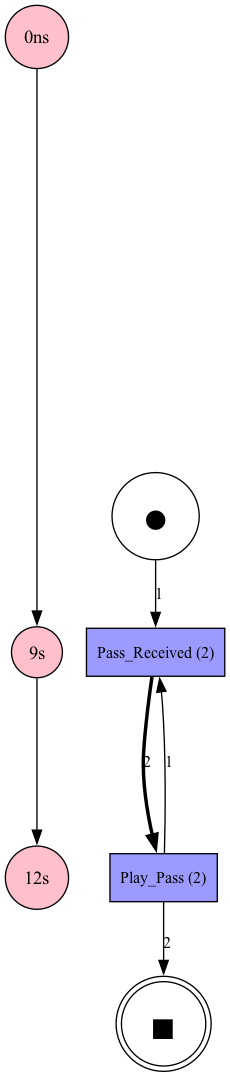

In [21]:
#log = shot_df[~shot_df['Forward'].isna()]
#log = shot_df[~shot_df['Midfielder'].isna()]
#log = shot_df[~shot_df['Defender'].isna()]
log = shot_df[~shot_df['Goalkeeper'].isna()]
#log=shot_df
dfg, start_act, end_act = pm4py.discover_dfg_typed(log)
dfg_time = clean_time.apply(log, parameters={"aggregation": "mean"})
gviz = timeline_gviz_generator.apply(dfg, dfg_time, parameters={"format": "png", "start_activities": start_act,
                                                                    "end_activities": end_act})
dfg_visualizer.view(gviz)

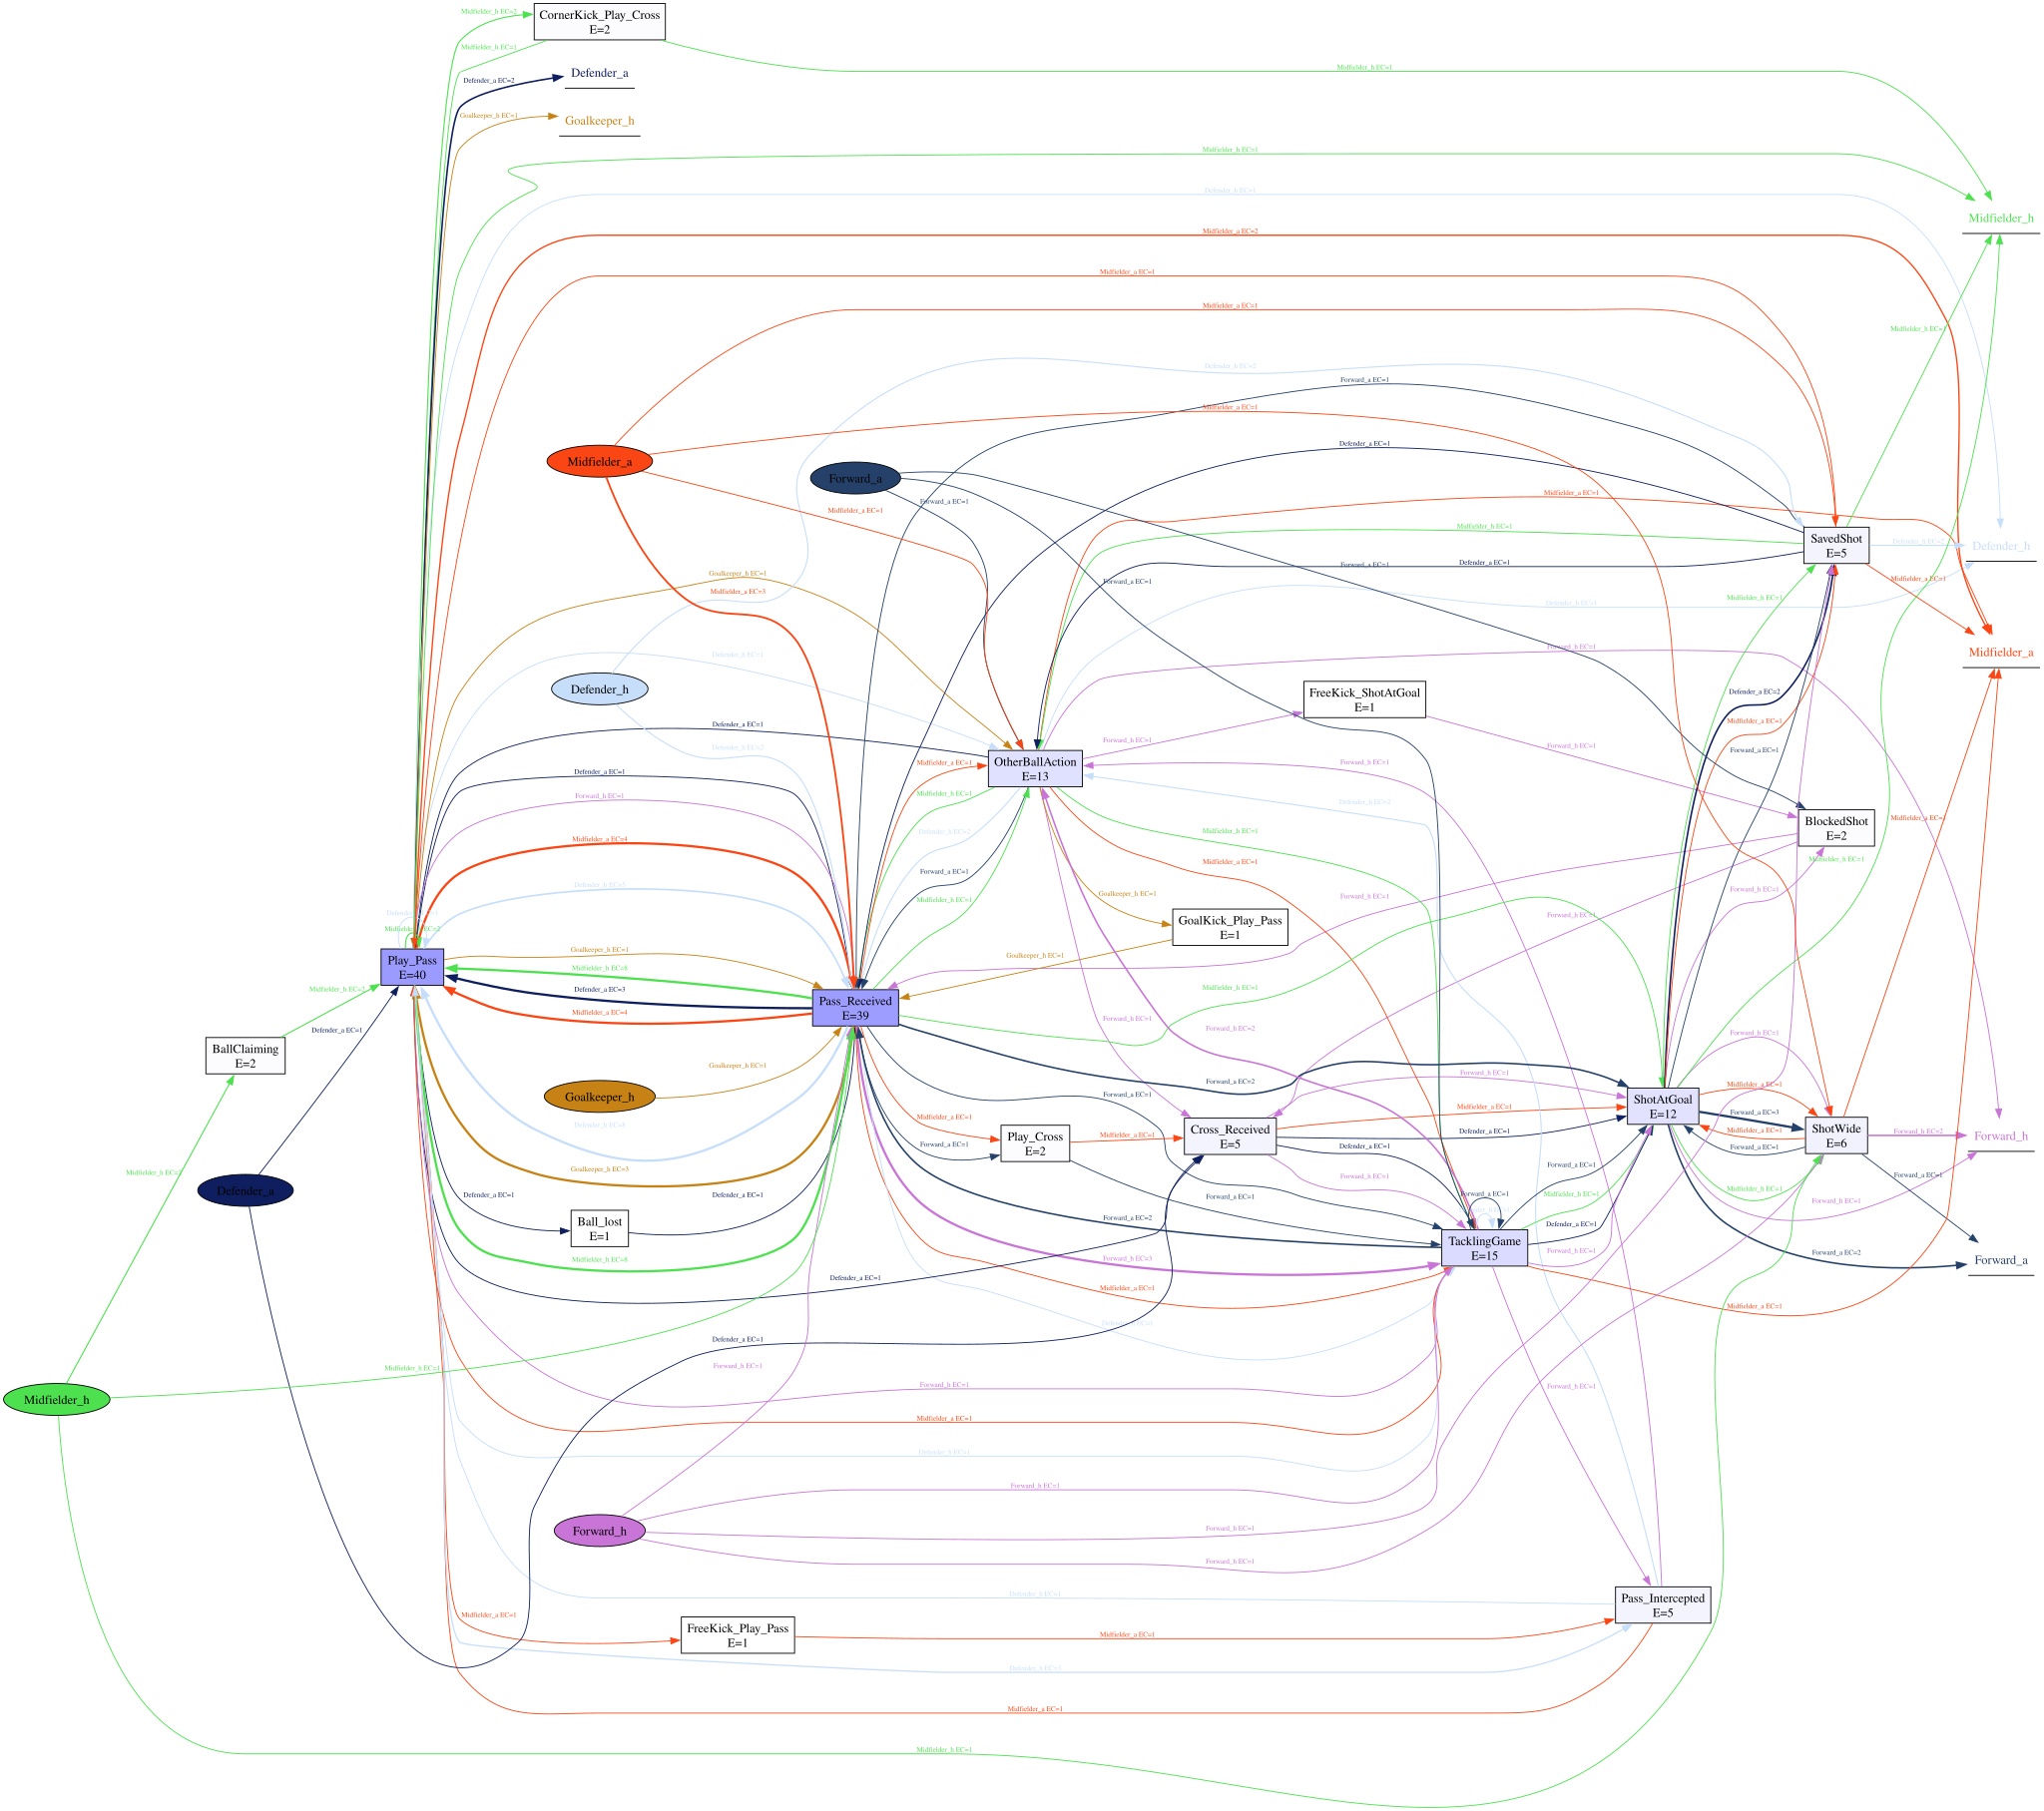

In [22]:
# convert to ocel
ocel= log_to_ocel_multiple_obj_types(event_log, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                     #'attacking_team', 'defending_team'
                                                     #'ball',
                                                     "Forward_h", "Midfielder_h", "Defender_h", "Goalkeeper_h"
                                                     ,"Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                     #,'Team','Player','Session', 'case:concept:name'
                                                     ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
dfg=pm4py.ocel.discover_ocdfg(ocel,business_hours=True)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)

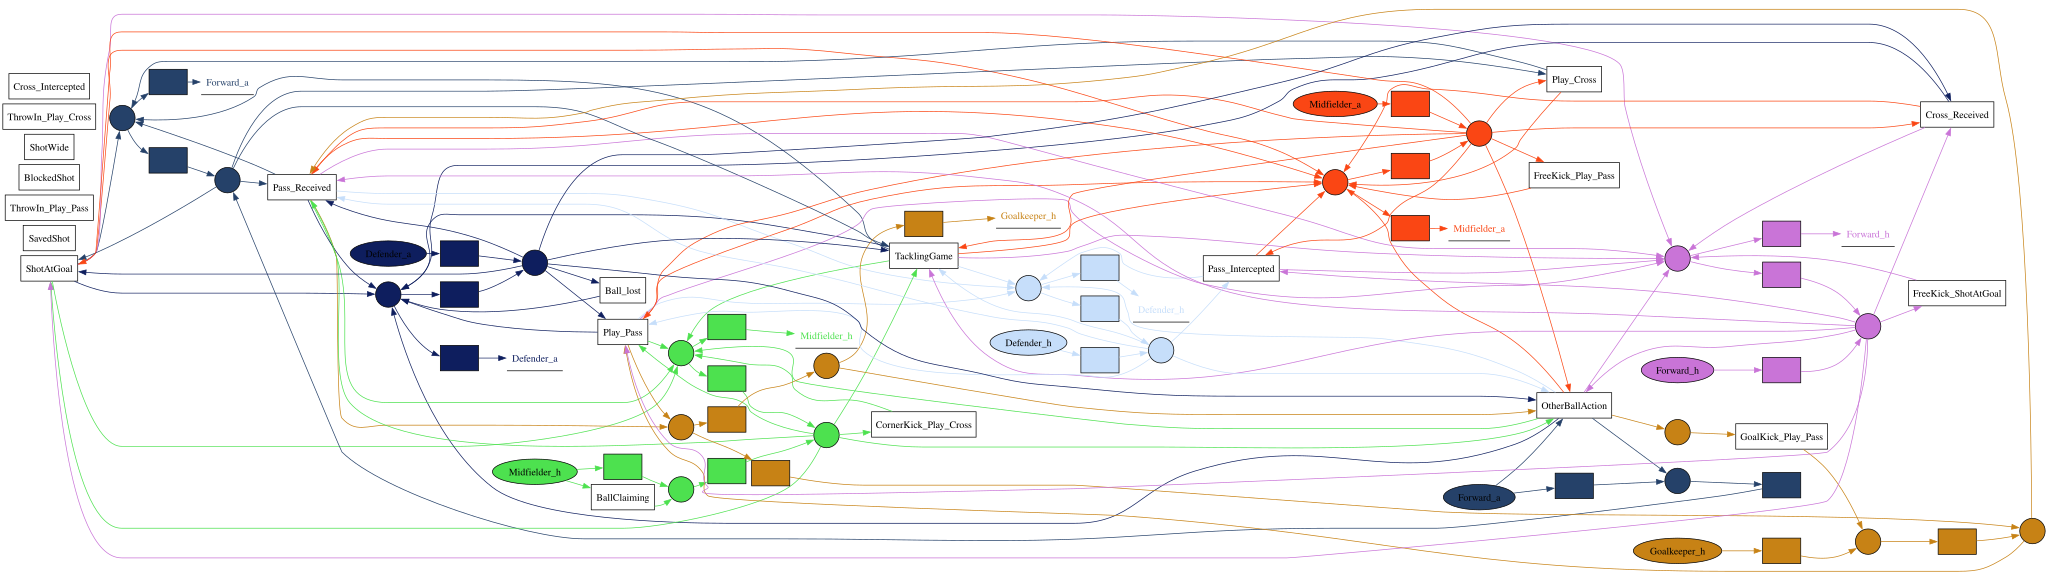

In [23]:
pn=pm4py.ocel.discover_oc_petri_net(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(pn)